## Práctica 3: Cálculo y visualización de Histogramas
### Autor: Juan Manuel Mena Hernandez
### Fecha: 03-03-2026


### EJERCICIO 1. CÁLCULO, VISUALIZACIÓN DEL HISTOGRAMA DE UNA IMAGEN
El primer paso para comprender la composición de una imagen es analizar su distribución de luminancia. 

Elaborar un programa que cargue una imagen en modo escala de gris, y que calcule en un array el número de píxeles que poseen cada uno de los 256 tonos posibles (el histograma)

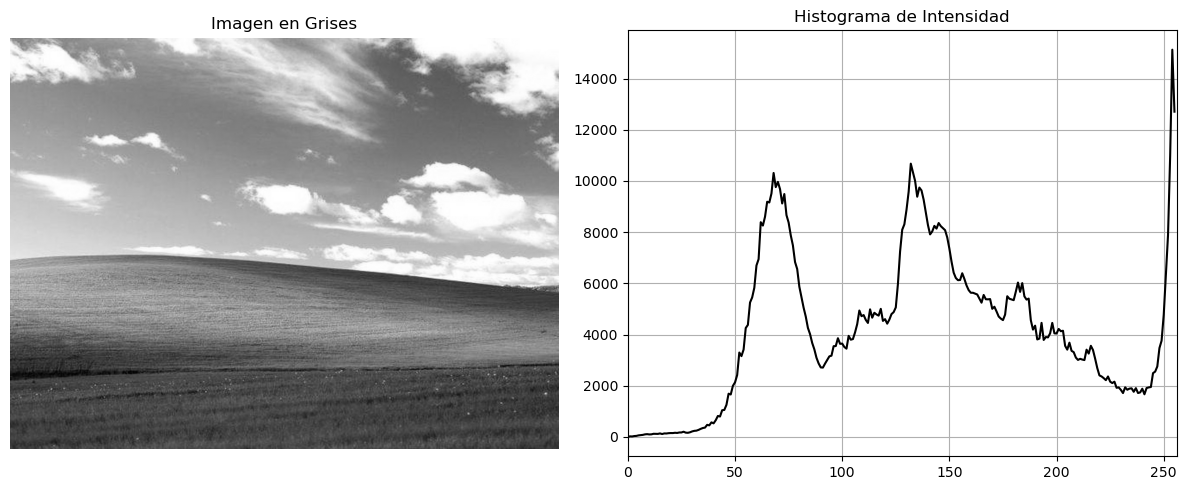

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Verificar si la imagen existe, si no crear una de prueba
if not Path('imagen.jpg').exists():
    print("Creando imagen de prueba...")
    imagen = np.random.randint(0, 256, (200, 300), dtype=np.uint8)
    cv2.imwrite('imagen.jpg', imagen)

# Cargar imagen a color
img = cv2.imread('imagen.jpg')

# Convertir a escala de gris
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Calcular el histograma
hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(gris, cmap='gray')
ax1.set_title('Imagen en Grises')
ax1.axis('off')

ax2.plot(hist, color='black')
ax2.set_title('Histograma de Intensidad')
ax2.set_xlim([0, 256])
ax2.grid(True)

plt.tight_layout()
plt.show()


El código hace tres cosas.

Primero, verifica que haya una imagen disponible en tu disco y la carga en la memoria.

Segundo, la pasa a blanco y negro para calcular su histograma, que es básicamente contar cuántos píxeles hay por cada nivel de luz u oscuridad.

Tercero, dibuja una ventana que te muestra la imagen de un lado y la gráfica de ese conteo del otro lado para que la puedas analizar.

### EJERCICIO 2. CÁLCULO, VISUALIZACIÓN DEL HISTOGRAMA DE CADA CANAL DE COLOR (RGB) DE UNA IMAGEN

En las imágenes en color, la información se divide habitualmente en tres canales: Rojo, Verde y Azul (RGB). 

Esta técnica es vital para identificar sesgos cromáticos o dominantes de color en una fotografía. En este ejercicio, se propone calcular el histograma de cada canal del color de una imagen y visualizarlo.


Imagen cargada: (900, 1200, 3)


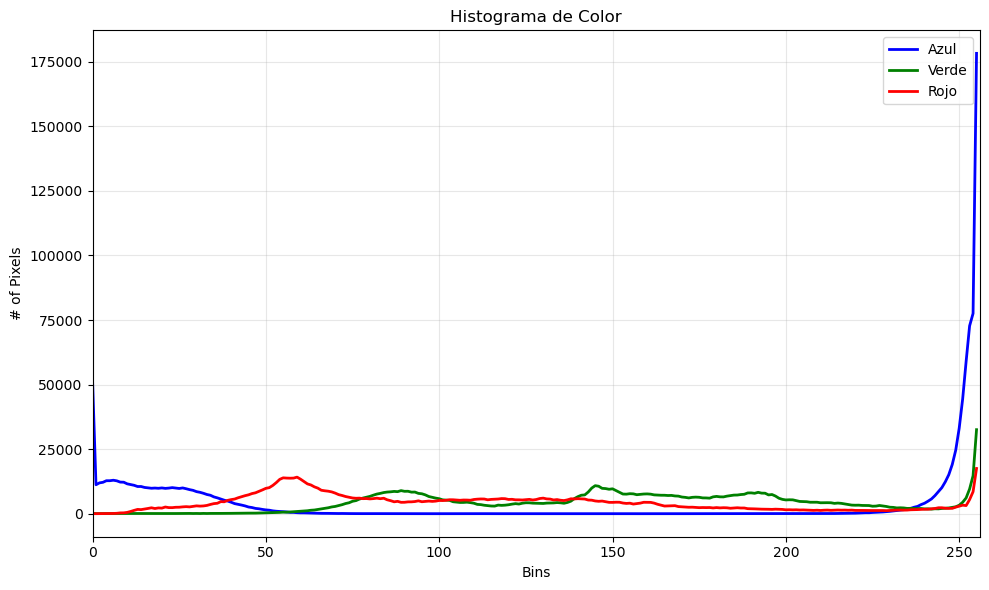

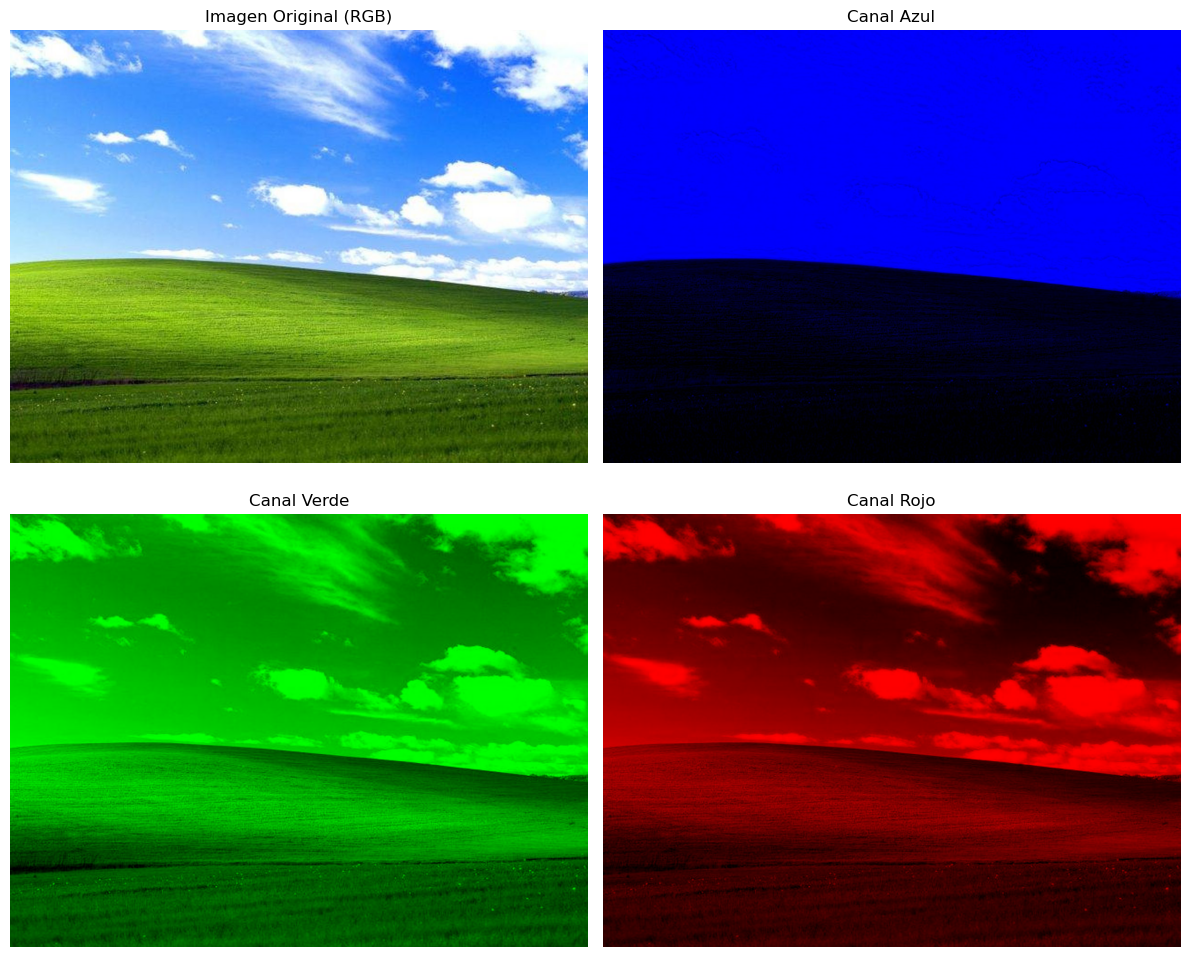

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Verificar si la imagen existe, si no crear una de prueba
if not Path('imagen.jpg').exists():
    print("Creando imagen de prueba...")
    imagen = np.random.randint(0, 256, (200, 300), dtype=np.uint8)
    cv2.imwrite('imagen.jpg', imagen)

# Cargar imagen a color
img = cv2.imread('imagen.jpg')

# Validar que la imagen se cargó correctamente
if img is None:
    raise ValueError("No se pudo cargar la imagen")

print(f"Imagen cargada: {img.shape}")

# Separar en canales
chans = cv2.split(img)
colors = ("b", "g", "r")
nombres_canales = ("Azul", "Verde", "Rojo")

# Crear figura para el histograma de color
plt.figure(figsize=(10, 6))
plt.title("Histograma de Color")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")

# Crear un histograma por cada canal
for (chan, color) in zip(chans, colors):
    hist = cv2.calcHist([chan], [0], None, [256], [0, 256])
    plt.plot(hist, color=color, linewidth=2)

plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.legend(["Azul", "Verde", "Rojo"])
plt.tight_layout()
plt.show()

# Visualización adicional: canales separados en color
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Imagen original en RGB (convertir de BGR a RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Imagen Original (RGB)')
axes[0, 0].axis('off')

# Crear imágenes de canales individuales en color
# Canal Azul (índice 0 en BGR)
azul_img = np.zeros_like(img)
azul_img[:, :, 0] = chans[0]  # Azul en OpenCV es el índice 0
azul_rgb = cv2.cvtColor(azul_img, cv2.COLOR_BGR2RGB)
axes[0, 1].imshow(azul_rgb)
axes[0, 1].set_title('Canal Azul')
axes[0, 1].axis('off')

# Canal Verde (índice 1 en BGR)
verde_img = np.zeros_like(img)
verde_img[:, :, 1] = chans[1]  # Verde en OpenCV es el índice 1
verde_rgb = cv2.cvtColor(verde_img, cv2.COLOR_BGR2RGB)
axes[1, 0].imshow(verde_rgb)
axes[1, 0].set_title('Canal Verde')
axes[1, 0].axis('off')

# Canal Rojo (índice 2 en BGR)
rojo_img = np.zeros_like(img)
rojo_img[:, :, 2] = chans[2]  # Rojo en OpenCV es el índice 2
rojo_rgb = cv2.cvtColor(rojo_img, cv2.COLOR_BGR2RGB)
axes[1, 1].imshow(rojo_rgb)
axes[1, 1].set_title('Canal Rojo')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Este código sigue una serie de pasos:

Primero, se asegura de cargar el archivo y lo desarma en sus tres canales de color fundamentales: azul, verde y rojo.

Segundo, calcula y dibuja un único gráfico con tres líneas de colores, el cual sirve para comparar cuántos píxeles hay de cada color en sus diferentes niveles de intensidad.

Tercero, genera una nueva ventana visual dividida en cuatro partes donde te muestra la foto original completa junto a tres variaciones, permitiéndote ver cómo se compone la imagen si solo miras su luz azul, su luz verde o su luz roja por separado.

### EJERCICIO 3. CÁLCULO, VISUALIZACIÓN DEL HISTOGRAMA DE UN ÁREA SELECCIONADA DE UNA IMAGEN

En muchas aplicaciones de visión artificial, nos interesa analizar únicamente una región de interés (ROI) en lugar de la imagen completa. En este ejercicio se pide aplicar una máscara para aislar un área específica y generar y visualizar un histograma que describa únicamente el contenido de dicha zona, evitando que el fondo o elementos irrelevantes distorsionen los datos.

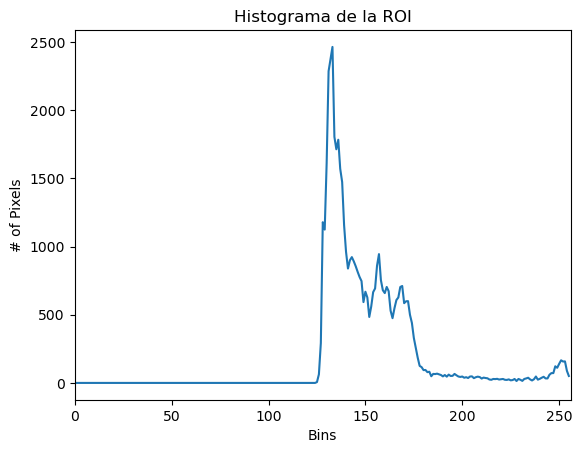

In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg', cv2.IMREAD_GRAYSCALE)

# Definir una región de interés (ROI)
roi = img[100:300, 150:400]

# Calcular el histograma del ROI
hist_roi = cv2.calcHist([roi], [0], None, [256], [0, 256])

plt.figure()
plt.title("Histograma de la ROI")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")
plt.plot(hist_roi)
plt.xlim([0, 256])
plt.show()


Este código lee una imagen directamente en blanco y negro y recorta una seccion rectangular específica de ella. 

Después, calcula el histograma exclusivamente para ese recorte, evaluando sus niveles de iluminación e ignorando el resto de la fotografía. 

Por último, dibuja y muestra en pantalla una ventana con la gráfica que representa la cantidad de pixeles oscuros y claros que hay solamente en esa porción que seleccionaste.

### EJERCICIO 4. AUMENTAR EL CONTRASTE DE LA IMAGEN (MULTIPLICANDO UNA CONSTANTE)

Este ejercicio propone aumentar el contraste de una imagen mediante la multiplicación de una constante y visualizar el resultado.


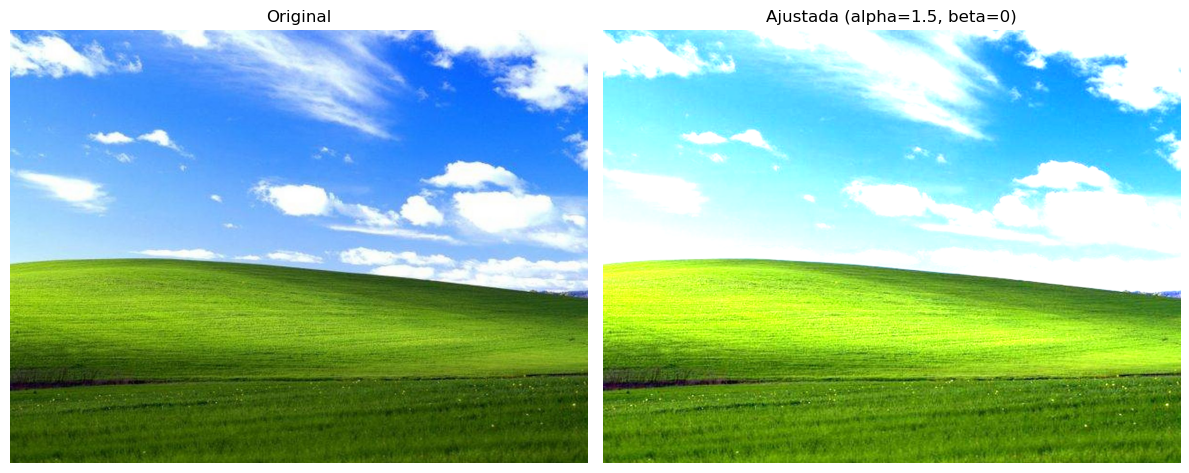

In [13]:
import cv2
import matplotlib.pyplot as plt

# Cargar la imagen
img = cv2.imread('imagen.jpg')

# Ajustar el brillo (beta) y contraste (alpha)
# Usando la fórmula: g(x) = alpha * f(x) + beta
alpha = 1.5
beta = 0
img_ajustada = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# Creamos una figura con 1 fila y 2 columnas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Imagen 1: Original
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.set_title('Original')
ax1.axis('off')

# Imagen 2: Ajustada
ax2.imshow(cv2.cvtColor(img_ajustada, cv2.COLOR_BGR2RGB))
ax2.set_title(f'Ajustada (alpha={alpha}, beta={beta})')
ax2.axis('off')

plt.tight_layout()
plt.show()


Este código hace dos cosas principales. 

Primero, carga una imagen y modifica su contraste multiplicando el valor de sus píxeles por un factor específico, lo que hace que las diferencias entre luces y sombras sean más marcadas, mientras deja su nivel de brillo intacto. 

Segundo, crea una ventana dividida en dos partes para mostrar la foto original de un lado y la versión modificada del otro, permitiéndote comparar visualmente el efecto del ajuste.

### EJERCICIO 5. COMPARAR 2 HISTOGRAMAS

La comparación de histogramas permite medir el grado de similitud entre dos imágenes basándose en su distribución de color o intensidad. 

Aquí exploraremos cómo utilizar métricas estadísticas (como la correlación o la distancia Chi-cuadrado) para determinar qué tan parecidas son dos capturas, una técnica fundamental en sistemas de búsqueda y reconocimiento de imágenes. Buscar 2 imágenes parecidas y comparar sus histogramas.


In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Cargar imagen 1
img1 = cv2.imread('imagen.jpg', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('imagen2.jpg', cv2.IMREAD_GRAYSCALE)

# Calcular los histogramas
hist1 = cv2.calcHist([img1], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([img2], [0], None, [256], [0, 256])

# Normalizar los histogramas
cv2.normalize(hist1, hist1)
cv2.normalize(hist2, hist2)

# Comparar los histogramas usando Correlación
comparison = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
print(f'Correlación: {comparison}')


Correlación: 0.39541890243733574


Este código realiza tres acciones principales para evaluar qué tan parecidas son dos imágenes distintas. 

Primero, carga ambas fotografías directamente en escala de grises. 

Segundo, calcula y normaliza el histograma de cada una, lo que significa que ajusta matemáticamente el conteo de sus píxeles para poder compararlas de forma justa incluso si tienen diferentes tamaños o resoluciones. 

Por último, calcula e imprime en pantalla el nivel de similitud entre las dos imágenes basándose en su distribución de luces y sombras utilizando un método estadístico llamado correlación.

### EJERCICIO 6. VISUALIZACIÓN DE HISTOGRAMAS RGB SUPERPUESTOS

Para facilitar la comparación visual entre los canales Rojo, Verde y Azul, es común graficarlos en una sola ventana utilizando transparencias. 

En este ejercicio se pide utilizar la librería Matplotlib para superponer las tres gráficas, permitiendo identificar rápidamente cuál es el color dominante en la escena.


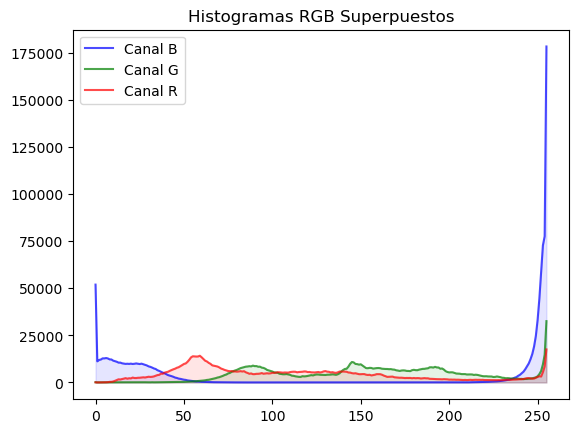

In [17]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('imagen.jpg')
colores = ('b', 'g', 'r')

for i, col in enumerate(colores):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col, alpha=0.7, label=f'Canal {col.upper()}')
    plt.fill_between(range(256), hist.flatten(), color=col, alpha=0.1)

plt.title('Histogramas RGB Superpuestos')
plt.legend()
plt.show()

Este código sigue dos pasos:

Primero, carga la imagen y calcula de manera individual la cantidad de píxeles que existen para cada uno de los tres colores básicos que la componen: azul, verde y rojo. 

Segundo, dibuja una única gráfica donde superpone las tres curvas resultantes, rellenando además el espacio debajo de cada línea con un color semitransparente para que puedas observar de forma clara y estética cómo se distribuyen y mezclan los tonos en toda la imagen.

Como se puede ver el canal azul es el más predominante.

### EJERCICIO 7. DETECCIÓN DE SUBEXPOSICIÓN Y SOBREEXPOSICIÓN MEDIANTE HISTOGRAMA

Una aplicación práctica del histograma es el control de calidad fotográfico. En este apartado se analiza si los píxeles se agrupan excesivamente en el valor 0 (subexposición) o en el 255 (sobreexposición o "quemado"), generando una alerta automática si la imagen ha perdido detalle en las sombras o en las luces. Realizar un script python que permita obtener dicha información a partir de las imágenes con las que se venga trabajando.


In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar la imagen original
img_original = cv2.imread('imagen.jpg', cv2.IMREAD_GRAYSCALE)
total_pixeles = img_original.shape[0] * img_original.shape[1]

# 2. Crear la imagen brillante (modificada)
matriz_brillo = np.full(img_original.shape, 100, dtype=np.uint8)
img_brillante = cv2.add(img_original, matriz_brillo)

# 3. Calcular histogramas
hist_original = cv2.calcHist([img_original], [0], None, [256], [0, 256])
hist_brillante = cv2.calcHist([img_brillante], [0], None, [256], [0, 256])

# 4. Calcular porcentajes de exposición
sub_orig = (hist_original[0] / total_pixeles) * 100
sobre_orig = (hist_original[255] / total_pixeles) * 100

sub_brill = (hist_brillante[0] / total_pixeles) * 100
sobre_brill = (hist_brillante[255] / total_pixeles) * 100

# 5. Mostrar resultados por consola
print("--- IMAGEN ORIGINAL ---")
print(f"Porcentaje píxeles negros: {sub_orig[0]:.2f}%")
print(f"Porcentaje píxeles blancos: {sobre_orig[0]:.2f}%")
if sub_orig[0] > 5: print("Alerta: Posible imagen subexpuesta")
if sobre_orig[0] > 5: print("Alerta: Posible imagen sobreexpuesta (quemada)")

print("\n--- IMAGEN BRILLANTE ---")
print(f"Porcentaje píxeles negros: {sub_brill[0]:.2f}%")
print(f"Porcentaje píxeles blancos: {sobre_brill[0]:.2f}%")
if sub_brill[0] > 5: print("Alerta: Posible imagen subexpuesta")
if sobre_brill[0] > 5: print("Alerta: Posible imagen sobreexpuesta (quemada)")

--- IMAGEN ORIGINAL ---
Porcentaje píxeles negros: 0.00%
Porcentaje píxeles blancos: 1.47%

--- IMAGEN BRILLANTE ---
Porcentaje píxeles negros: 0.00%
Porcentaje píxeles blancos: 38.92%
Alerta: Posible imagen sobreexpuesta (quemada)


Este código sigue tres pasos para analizar la exposición de una fotografía. 

Primero, carga una imagen en escala de grises y genera una segunda versión artificialmente más brillante sumando un valor fijo a todos sus píxeles. 

Segundo, calcula los histogramas de ambas versiones para identificar la cantidad exacta de píxeles que son puramente negros o puramente blancos. 

Tercero, calcula el porcentaje que representan estos píxeles extremos sobre el total de la imagen e imprime los resultados en la consola, mostrando una advertencia automática si detecta que alguna de las dos imágenes está demasiado oscura o demasiado quemada.